# **Exploratory Data Analysis (EDA) on Tips Dataset**

In [1]:
#Import & Load Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


**Task 1: Distribution Analysis Using Histograms**

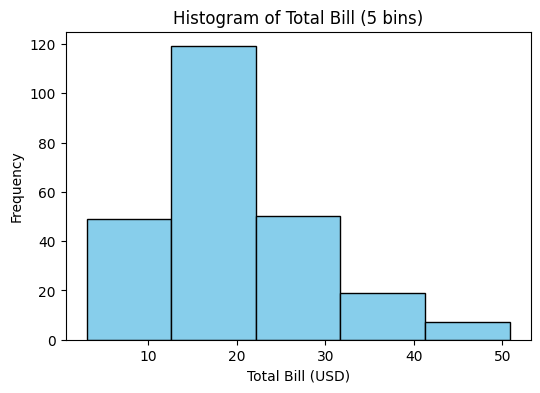

In [2]:
#Histogram with 5 bins

plt.figure(figsize=(6,4))
plt.hist(df['total_bill'], bins=5, color='skyblue', edgecolor='black')
plt.xlabel('Total Bill (USD)')
plt.ylabel('Frequency')
plt.title('Histogram of Total Bill (5 bins)')
plt.show()

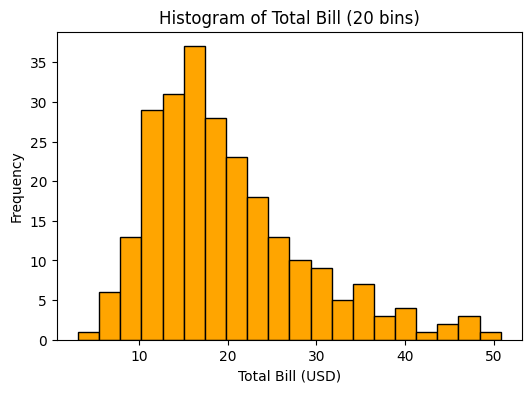

In [3]:
#Histogram with 20 bins

plt.figure(figsize=(6,4))
plt.hist(df['total_bill'], bins=20, color='orange', edgecolor='black')
plt.xlabel('Total Bill (USD)')
plt.ylabel('Frequency')
plt.title('Histogram of Total Bill (20 bins)')
plt.show()

**What does the distribution of total_bill look like — is it symmetric, left-skewed, or right-skewed?**           
The distribution of the total_bill is right-skewed (positively skewed).
Most of the values are concentrated on the lower side (around 10–20 USD), while a few high-value bills extend towards the right side, creating a long tail.

**How does changing the number of bins affect your ability to interpret the distribution?**                           
Increasing bins (20 bins):
Shows more detail and finer distribution patterns                                   
Fewer bins (5 bins):
Gives a general overview but hides small variations

# **Task 2: Outlier Detection Using Box Plots**

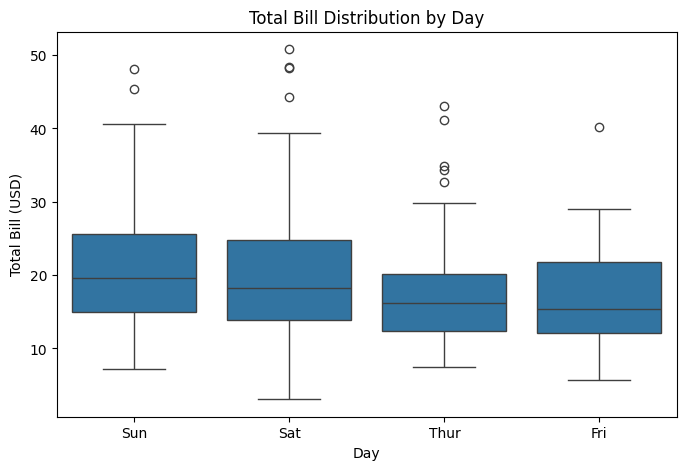

In [4]:
plt.figure(figsize=(8,5))
sns.boxplot(x='day', y='total_bill', data=df)
plt.xlabel('Day')
plt.ylabel('Total Bill (USD)')
plt.title('Total Bill Distribution by Day')
plt.show()

In [ ]:
#IQR Calculation Example (for Saturday)

# Group by day and calculate Q1, Q3, IQR
q1 = df.groupby('day')['total_bill'].quantile(0.25)
q3 = df.groupby('day')['total_bill'].quantile(0.75)
iqr = q3 - q1

print("Q1:\n", q1)
print("\nQ3:\n", q3)
print("\nIQR:\n", iqr)
lower_bound = q1['Sat'] - 1.5 * iqr['Sat']
upper_bound = q3['Sat'] + 1.5 * iqr['Sat']
print("\nSaturday Lower Bound:", lower_bound)
print("Saturday Upper Bound:", upper_bound)
outliers = df[(df['day']=='Sat') & ((df['total_bill'] < lower_bound) | (df['total_bill'] > upper_bound))]
outliers

**On which day does the median total bill appear highest?**                    
The median total bill appears highest on Saturday (Sat).
This indicates that customers tend to spend more on Saturdays compared to other days.

**Identify at least one day that appears to have outliers. Calculate the IQR for that day manually using df.groupby() and quantile(), and verify whether the points you identified qualify as outliers using the standard rule: Q1 − 1.5×IQR and Q3 + 1.5×IQR.**                 
Using IQR:
Values outside Q1 − 1.5×IQR and Q3 + 1.5×IQR are confirmed as outliers.           
Saturday shows several high-value bills beyond the upper bound.

# **Task 3: Multi-Variable Comparison Using an Interactive Plot**

In [5]:
import plotly.express as px

fig = px.scatter(
    df,
    x='total_bill',
    y='tip',
    color='time',
    hover_data=['day', 'size'],
    title='Total Bill vs Tip (Colored by Time)'
)

fig.show()

**Does there appear to be a relationship between total_bill and tip?**
There is a positive relationship between total_bill and tip:

As the bill increases, tips also increase.

**Do Lunch and Dinner transactions differ noticeably in their tipping patterns? What does the color separation reveal?**             
Dinner transactions generally have:

Higher bills

Higher tips compared to Lunch

**dentify one specific data point (visible via hover) that you find interesting or unusual, and briefly explain why.**                            
The color separation shows:

Dinner dominates higher-value transactions
Lunch is clustered in lower ranges